# **TBNN Basis Exploration**
### Understanding How Strain and Rotation Build Turbulent Anisotropy

Turbulent mixing layers don’t follow simple eddy-viscosity ideas — the Reynolds stresses are tied to how the local strain-rate **S** and rotation-rate **R** interact.  
A Tensor-Basis Neural Network represents the anisotropy tensor

$$
a_{ij} = \frac{\overline{u_i'u_j'}}{2k} - \frac{1}{3}\delta_{ij}
$$
as a sum of tensor basis elements:

$$
a_{ij} = \sum_{n} g^{(n)} T^{(n)}_{ij}(S,R)
$$
### The Boussinesq hypothesis 
Used in CFD to approximate reynolds stresses using a modeled term, eddy-viscosity ($\nu_t$)
$$
\tau_{ij} = -2 \nu_t S_{ij} + \frac{2}{3}k\,\delta_{ij}
$$
$$a_{ij} = \frac{\tau_{ij}}{2k} - \frac{1}{3}\delta_{ij}$$
$$a_{ij} = -\frac{\nu_t}{k} S_{ij}$$
The work done is as follows:

- Build set of $S$ and $R$ tensors and variants so I can  
- compute the matching scalar invariants  
- check which basis elements are redundant or nearly collinear  
- solve for the TBNN coefficients \(g_n\)  
- look at how \(g_n\) varies across the flow

Basically: figure out which combinations of \(S\), \(R\), and their products actually matter for closing the anisotropy.

This is the workspace for testing those ideas.


## Now we have tensors for $a_{ij}, \tau_{ij}, S_{ij}$ in dim and nondim forms
### Okay so the goal here is to find a correlation between our original tensorbase and anisotropy
## Reduced Tensor Basis (Test 1)

We analyze the following five–term reduced tensor basis:
$$
\begin{aligned}
T_1 &= S, \\
T_2 &= SR - RS, \\
T_3 &= S^2 - \tfrac{1}{3}\,\mathrm{tr}(S^2)\,I, \\
T_4 &= R^2 - \tfrac{1}{3}\,\mathrm{tr}(R^2)\,I, \\
T_5 &= RS^2 - S^2R,
\end{aligned}
$$
with anisotropy modeled as
$$
a_{ij} \approx \sum_{n=1}^5 g_n T^{(n)}_{ij}.
$$

#### Import packages and set data root

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.interpolate import griddata

data_root = os.path.join(os.getcwd(), '..', 'Data')
dataset = 'Shear_mixing'
dataset_root = os.path.join(data_root, dataset)
print(dataset_root)

/Users/elliotporter/Desktop/Turb_research/Turb_PL/tutorials/../Data/Shear_mixing


### load dfs (dnd) and organize into matrices (R, S, rst, aij, k) for a given case fov

In [32]:
#setup data you want to run 
#feature engineering trial
fe_name = "FEPL_og_20251118"
case = 'Case1'
nd = 'nondim'
dim = 'dim'
dnds = ['dim', 'nondim']
fov = 'FOV1'
ckpt = 'chkpt6_train'

rans_data = {}
exp_data = {}

for dim in dnds:
    rans_path = os.path.join(dataset_root, fe_name, f'{case}_{ckpt}_{fov}_rans_{dim}.pkl')
    exp_path = os.path.join(dataset_root, fe_name, f'{case}_{ckpt}_{fov}_exp_{dim}.pkl')

    rans_df = pd.read_pickle(rans_path)
    exp_df = pd.read_pickle(exp_path)

    rans_data[dim] = rans_df.copy()
    exp_data[dim] = exp_df.copy()

#Org strain, rot, aij, and rst data
indices = ['_xx', '_xy', '_xz', '_yy', '_yz', '_zz']
rotation = ['R' + tail for tail in indices]
strain = ['S' + tail for tail in indices]
anis = ['a' +  tail for tail in indices]
rst = ['uu','uv', 'vv', 'ww'] # uw vw not in dfs
grid_dims = ['Cx', 'Cy']
eps = 'turb-diss-rate'
k_rans = 'k'
grid_data = {'dim': rans_data['dim'][grid_dims],
                'nondim': rans_data['nondim'][grid_dims]}
rotation_data = {'dim': rans_data['dim'][rotation],
               'nondim': rans_data['nondim'][rotation]}
strain_data = {'dim': rans_data['dim'][strain],
               'nondim': rans_data['nondim'][strain]}
anis_data = {'dim': exp_data['dim'][anis],
               'nondim': exp_data['nondim'][anis]}
rst_data = {'dim': exp_data['dim'][rst],
               'nondim': exp_data['nondim'][rst]}
k_rans_data = {
    'dim': rans_data['dim'][k_rans].astype(float).values, 
    'nondim': rans_data['nondim'][k_rans].astype(float).values
}
epsilon_rans_data = {
    'dim': rans_data['dim'][eps].astype(float).values, 
    'nondim': rans_data['nondim'][eps].astype(float).values
}
import os, sys, numpy as np

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

# === NumPy tensor utils ===
from utils.numpy_tensor_utils import (
    rst_vec4_to_mat33_numpy as rst_to_mat33_np,  # <-- correct for vec4 RST
    vec6_to_mat33 as vec6_to_mat33_np,           # <-- only for Aij, Sij, Rij
    trace_numpy,
    deviatoric_numpy, 
    enforce_2d_plane_tensor as enforce_2d)

# Convert vec4 → mat33 for RST
rst_mtx33 = {'dim':    rst_to_mat33_np(rst_data['dim']),
             'nondim': rst_to_mat33_np(rst_data['nondim'])}

# Convert vec6 → mat33 for the OTHER tensors
aij_mtx33 = {'dim':    enforce_2d(vec6_to_mat33_np(anis_data['dim'])),
             'nondim': enforce_2d(vec6_to_mat33_np(anis_data['nondim']))}

Sij_mtx33 = {'dim':    enforce_2d(vec6_to_mat33_np(strain_data['dim'])),
             'nondim': enforce_2d(vec6_to_mat33_np(strain_data['nondim']))}

Rij_mtx33 = {'dim':    enforce_2d(vec6_to_mat33_np(rotation_data['dim'])),
             'nondim': enforce_2d(vec6_to_mat33_np(rotation_data['nondim']))}
# Compute TKE (k = 1/2 * trace(Rij))
k_scalar = {'dim':    0.5 * trace_numpy(rst_mtx33['dim']),
            'nondim': 0.5 * trace_numpy(rst_mtx33['nondim'])}


#### Plot feature func

In [3]:
def plot_feature(df, var='Ux', t='Rans', fov='FOV1', case='Case1', cmap='jet', smooth=True, grid=200, shading='auto'):
    plt.figure(figsize=(12, 5))
    if smooth:
        X = np.linspace(df['Cx'].min(),df['Cx'].max(), grid)
        Y = np.linspace(df['Cy'].min(),df['Cy'].max(), grid)
        x, y = np.meshgrid(X,Y)
        z = griddata((df['Cx'], df['Cy']), df[var], (x, y), method='linear')
    else:
        x, y = df['Cx'], df['Cy']
        z = df[var]
    # --- Determine shared limits ---
    xlims = (df['Cx'].min(), df['Cx'].max())
    ylims = (df['Cy'].min(),df['Cy'].max())

    if smooth:
        vmin = np.nanmin([z])
        vmax = np.nanmax([z])
    else:
        vmin = vmax = None
    if smooth:
        pcm = plt.pcolormesh(x, y, z, shading=shading, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pcm = plt.scatter(x, y, c=z, s=2, cmap=cmap)
    plt.colorbar(pcm, label=var)
    plt.xlabel("Cx [m]")
    plt.ylabel("Cy [m]")
    plt.xlim(*xlims)
    plt.ylim(*ylims)
    plt.tight_layout()
    plt.show()

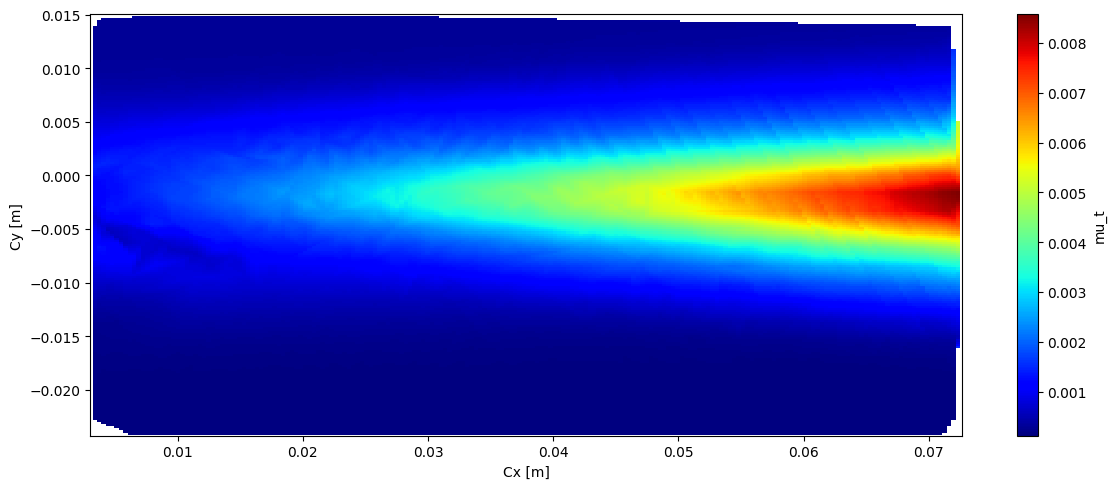

In [153]:
#sample plotting

feature = 'mu_suth'
exp_feat = 'a_xy'
feature = 'mu_t'
plot_feature(rans_data['dim'], 'mu_t', 'Rans', fov, case, cmap='jet', smooth=True, grid=200)
#plot_feature(rans_data['nondim'], feature, 'Rans', fov, case, 'jet')
#plot_feature(exp_data['dim'], exp_feat, 'Exp', fov, case, 'jet')
#plot_feature(exp_data['nondim'], exp_feat, 'Exp', fov, case, 'jet')

#### Make reduced tensor base and solve for coefficients funcitons

In [88]:
import numpy as np


def trace2(T):
    """tr(T^2) = sum_ij T_ik T_kj."""
    return np.einsum('...ik,...kj->...ij', T, T).trace(axis1=-2, axis2=-1)

def double_contraction(A, B):
    A = np.asarray(A)
    B = np.asarray(B)
    # 2D input (3×3)
    if A.ndim == 2:
        return np.sum(A * B)
    # Batched input (N×3×3)
    elif A.ndim == 3:
        return np.sum(A * B, axis=(1, 2))
    else:
        raise ValueError(f"Unexpected tensor shape {A.shape}, expected (3,3) or (N,3,3)")

def dev_numpy(T):
    T = np.asarray(T)

    # Case 1: single tensor (3×3)
    if T.ndim == 2:
        tr = np.trace(T)
        return T - (tr / 3.0) * np.eye(3)

    # Case 2: batch of tensors (N×3×3)
    elif T.ndim == 3:
        tr = np.trace(T, axis1=1, axis2=2)[..., None, None]
        I = np.eye(3)[None, :, :]
        return T - (tr / 3.0) * I

    else:
        raise ValueError(f"deviatoric_numpy expects shape (3,3) or (N,3,3), got {T.shape}")
def normalize_SR(S, R, k, eps=1e-8):
    S2 = S @ S
    R2 = R @ R
    theta = np.sqrt(np.trace(S2) + np.trace(R2)) + eps
    return S / theta, R / theta, k / theta

def normalize_keps(S, R, k, epsilon, eps=1e-8):
    #eps is buffer term epsilon, epsilon is dissipation rate
    keps = k/(epsilon + eps)
    return S * keps, R*keps, k*keps


def normalize_k_order(tensor_dict, k, eps=1e-12):
    """
    Applies k-order scaling to each tensor basis:
      S      → S/k
      R      → R/k
      S2     → S2/k^2
      R2     → R2/k^2
      S3     → S3/k^3
      ...
    Assumes tensor_dict entries are (3,3) numpy arrays.
    k is scalar (per-point if looping).
    """
    k = float(k) + eps  # ensure scalar & avoid divide-by-zero
    scaled = {}

    # Define polynomial order for each basis term
    poly_order = {
        "S": 1, "R": 1,
        "S_dev": 1, "R_dev": 1,
        "S2": 2, "R2": 2,
        "S2_dev": 2, "R2_dev": 2,
        "S_dev2": 2, "R_dev2": 2,
        "SR": 2, "RS": 2,
        "SR-RS": 2,
        "RS2-S2R": 3,
        "S3": 3, "R3": 3
    }

    for name, T in tensor_dict.items():
        if name not in poly_order:
            raise ValueError(f"No k-order defined for tensor '{name}'")

        p = poly_order[name]       # polynomial order
        scale = k ** p             # compute scaling factor

        scaled[name] = T / scale   # apply normalization

    return scaled

def norm_tensors(S, R, K, epsilon, norm=None):
    if norm == None:
        return S, R, K
    if norm.lower() =='k_order':
        return S, R, K 
    if norm.lower()=='keps':
        return normalize_keps(S, R, K, epsilon)
    elif norm.lower() == 'sr':
        return normalize_SR(S, R, K)
    return

def build_basis_tensors(S, R, k, config):
    """Return only the tensors that form the regression basis."""
    
    # --- Base tensors ---
    S2 = S @ S
    R2 = R @ R
    S3 = S2 @ S
    R3 = R2 @ R

    # Deviatoric versions
    S_dev = dev_numpy(S)
    R_dev = dev_numpy(R)

    S2_dev = dev_numpy(S2)
    R2_dev = dev_numpy(R2)

    S_dev2 = S_dev @ S_dev
    R_dev2 = R_dev @ R_dev

    # Mixed tensors
    SR  = S @ R
    RS  = R @ S
    RS2 = R @ S2
    S2R = S2 @ R
    RS2_S2R = RS2 - S2R
    SRS2_S2RS = S @ RS2 - S2R @ S
    SR_RS = SR - RS

    # Full dictionary
    all_tensors = {
        "S": S,
        "R": R,
        "S_dev": S_dev,
        "R_dev": R_dev,
        "S2": S2,
        "R2": R2,
        "S2_dev": S2_dev,
        "R2_dev": R2_dev,
        "S_dev2": S_dev2,
        "R_dev2": R_dev2,
        "SR": SR,
        "RS": RS,
        "SR-RS": SR_RS,
        "RS2-S2R": RS2_S2R,
        "S3": S3,
        "R3": R3
    }

    # Select only those requested
    tensor_keys = config.get("tensors", [])
    selected = {}
    for k in tensor_keys:
        if k not in all_tensors:
            raise ValueError(f"Requested tensor '{k}' is not in tensor bank!")
        selected[k] = all_tensors[k]
    #now norm by k. 
    #if term is 1st order, div by k
    # if term is 2nd order div by k
    return selected
def compute_invariants_batch(S_list, R_list, k_list=None):
    """
    Vectorized computation of invariants for all S,R pairs.
    Returns dict mapping invariant name → array of shape (N,).
    """

    # --- Precompute common tensors ---
    S2 = S_list @ S_list
    R2 = R_list @ R_list
    S3 = S2 @ S_list
    R3 = R2 @ R_list

    # Deviatoric operator
    def dev(A):
        tr = np.trace(A, axis1=1, axis2=2)[:, None, None]
        I  = np.eye(3)[None, :, :]
        return A - tr/3 * I

    S_dev    = dev(S_list)
    R_dev    = dev(R_list)
    S2_dev   = dev(S2)
    R2_dev   = dev(R2)
    S_dev2   = S_dev @ S_dev
    R_dev2   = R_dev @ R_dev

    SR       = S_list @ R_list
    RS       = R_list @ S_list

    # --- Double contraction helper (vectorized) ---
    def dcon(A, B):
        return np.sum(A * B, axis=(1,2))

    # --- Invariants (all shape = (N,)) ---
    inv = {}

    inv["tr_S"]       = np.trace(S_list, axis1=1, axis2=2)
    inv["tr_R"]       = np.trace(R_list, axis1=1, axis2=2)
    inv["tr_S_dev"]   = np.trace(S_dev, axis1=1, axis2=2)
    inv["tr_R_dev"]   = np.trace(R_dev, axis1=1, axis2=2)

    inv["tr_S2"]      = np.trace(S2, axis1=1, axis2=2)
    inv["tr_R2"]      = np.trace(R2, axis1=1, axis2=2)
    inv["tr_S2_dev"]  = np.trace(S2_dev, axis1=1, axis2=2)
    inv["tr_R2_dev"]  = np.trace(R2_dev, axis1=1, axis2=2)

    inv["tr_S3"]      = np.trace(S3, axis1=1, axis2=2)
    inv["tr_R3"]      = np.trace(R3, axis1=1, axis2=2)

    inv["tr_S_dev2"]  = np.trace(S_dev2, axis1=1, axis2=2)
    inv["tr_R_dev2"]  = np.trace(R_dev2, axis1=1, axis2=2)

    inv["S:R"]        = dcon(S_list, R_list)
    inv["S2:R"]       = dcon(S2, R_list)
    inv["S:R2"]       = dcon(S_list, R2)
    inv["S2:R2"]      = dcon(S2, R2)
    inv["SR:RS"]      = dcon(SR, RS)
    inv["SR2:S2R"]    = dcon(R_list @ S2, S2 @ R_list)

    # Optional — include TKE
    if k_list is not None:
        inv["k"] = k_list

    return inv

def flatten_sym(M):
    return np.array([M[0,0], M[0,1], M[0,2], M[1,1], M[1,2], M[2,2]])

def flatten_tensor_dict(tensor_dict):
    mats = []
    names = []

    for name, T in tensor_dict.items():
        T = np.asarray(T)
        if T.shape != (3,3):
            raise ValueError(f"Tensor '{name}' has shape {T.shape}, expected (3,3)")
        vec = flatten_sym(T)
        mats.append(vec)
        names.append(name)

    B = np.column_stack(mats)
    return B, names
    
def solve_coefficients(a_ij, basis):
    a_vec = flatten_sym(a_ij)
    
    B = np.column_stack([flatten_sym(T) for T in basis])  # 6 x N
    g, *_ = np.linalg.lstsq(B, a_vec, rcond=None)
    return g  # array of coefficients


#### Solving for coefficients with with options for k or dnd and plot

In [294]:
good_tensor_sets = {'simple': ["S", "S2", "S2_dev", "S_dev2"],
                   'two': ["S", "S2", "S2_dev", "S_dev2"],
                   }


configs = {
    # 1. Minimal BANK (S, R only)
   
    "minimal": {
        'dnd': 'dim',
        'k':{'use_k': True,
             'rans_k': True},
        "tensors": ["S", "R"],
        "invariants": ["tr_S", "tr_R", "S:R"],
        "norm": {
            "enabled": False,
            "type": None }      # "sr" or "keps"
        },
    "reduced": {'dnd': 'dim',
        'k':{'use_k': True,
             'rans_k': True},
        "tensors": ["S", "R", "S2_dev", "SR-RS"], # "RS2-S2R"],
        "invariants": ["tr_S", "tr_S2",],
        "norm": {
            "enabled": True,
            "type": 'k_order' }      # "sr" or "keps" or 'k_order'
        },
}


In [213]:

def run_analysis(config):
    dnd = config['dnd']
    S_list = Sij_mtx33[dnd]
    R_list = Rij_mtx33[dnd]
    a_list = aij_mtx33[dnd]
    k_exp  = np.array(k_scalar[dnd], dtype=float).flatten()
    k_rans = np.array(k_rans_data[dnd], dtype=float).flatten()
    eps_list = np.array(epsilon_rans_data[dnd], dtype=float).flatten()
    
    k_list = k_rans if config['k']['use_k'] else k_exp
    g_all = []
    g_k_all = []
    # ----- Coefficient regression -----
    for S, R, a, k, eps in zip(S_list, R_list, a_list, k_list, eps_list):
        S, R, k = norm_tensors(S, R, k, eps)
    
        tensors = build_basis_tensors(S, R, k, config)
    
        # ---- APPLY K-ORDER ONLY HERE ----
        if config["norm"]["type"] == "k_order":
            tensors = normalize_k_order(tensors, k)
    
        B, basis_names = flatten_tensor_dict(tensors)
        a_vec = flatten_sym(a)
        g = np.linalg.lstsq(B, a_vec, rcond=None)[0]
        g_all.append(g)
        if k > 1e-12:
            g_k_all.append(g / k)
        else:
            g_k_all.append(np.zeros_like(g))

    g_all = np.array(g_all)
    g_k_all = np.array(g_k_all)
    # ----- Invariants (ALL AT ONCE) -----
    invariants = compute_invariants_batch(S_list, R_list, k_list)

    return g_all, g_k_all, invariants


        


In [159]:
def plot_g_coeffs(g_all, k_norm=False):
    """
    Plot each coefficient g_i as a vertical scatter distribution.
    x-axis = coefficient index (1, 2, 3, ...)
    y-axis = values of g_i at all points.
    """
    Ng = g_all.shape[1]

    plt.figure(figsize=(1.6*Ng, 5))

    for i in range(Ng):
        # small jitter so points don't overlap perfectly
        x_jitter = (np.random.rand(len(g_all[:, i])) - 0.5) * 0.12
        
        plt.scatter(
            np.full_like(g_all[:, i], i+1) + x_jitter,
            g_all[:, i],
            s=6,
            alpha=0.5
        )

    # axis setup
    plt.xticks(range(1, Ng+1), [f"g{i+1}" for i in range(Ng)])
    plt.ylabel("Coefficient value")

    if k_norm:
        plt.title("TBNN Coefficients (scaled by k)")
    else:
        plt.title("TBNN Reduced-Basis Coefficients")

    plt.grid(alpha=0.2, linestyle='--')
    plt.tight_layout()
    plt.show()

### Visualize tensor basis coefficients on map

In [10]:
#plotting funcitons
dnd = cfg['dnd']
Cx, Cy = grid_data[dnd]['Cx'], grid_data[dnd]['Cy']

import pandas as pd

def coef_df(Cx, Cy, g_all, idx):
    """Build a dataframe {Cx, Cy, g_i} for plotting."""
    return pd.DataFrame({
        'Cx': Cx,
        'Cy': Cy,
        f'g{idx+1}': g_all[:, idx]
    })

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def plot_all_g(Cx, Cy, g_all, smooth=True, grid=200, cmap='coolwarm', knorm=False):
    n_g = g_all.shape[1]
    ncols = 3
    nrows = int(np.ceil(n_g / ncols))

    if smooth:
        X = np.linspace(Cx.min(), Cx.max(), grid)
        Y = np.linspace(Cy.min(), Cy.max(), grid)
        Xg, Yg = np.meshgrid(X, Y)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5*ncols, 5*nrows),
        constrained_layout=True
    )
    axes = axes.flatten()

    for i in range(n_g):
        ax = axes[i]
        gi = g_all[:, i]

        if smooth:
            Z = griddata((Cx, Cy), gi, (Xg, Yg), method='linear')
            pcm = ax.pcolormesh(Xg, Yg, Z, cmap=cmap, shading='auto')
        else:
            pcm = ax.scatter(Cx, Cy, c=gi, s=4, cmap=cmap)

        ax.set_title(f"g{i+1}")
        ax.set_aspect('equal')
        fig.colorbar(pcm, ax=ax)

    for j in range(n_g, len(axes)):
        axes[j].axis('off')
    
    if knorm:
        plt.title("K Normed coefficients mapped")
    else:
        plt.title("Coefficients mapped")
    plt.show()


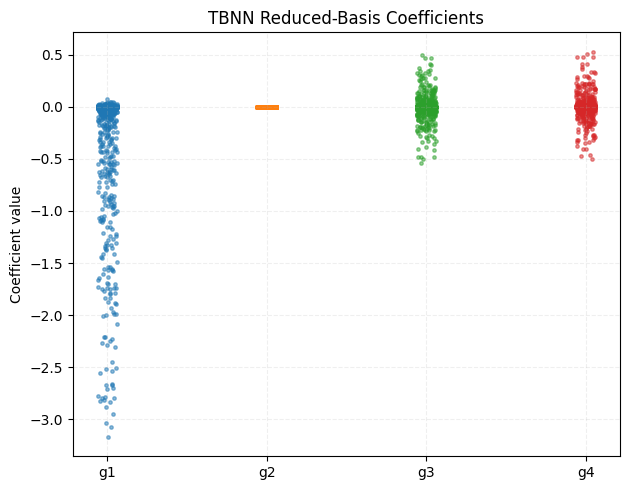

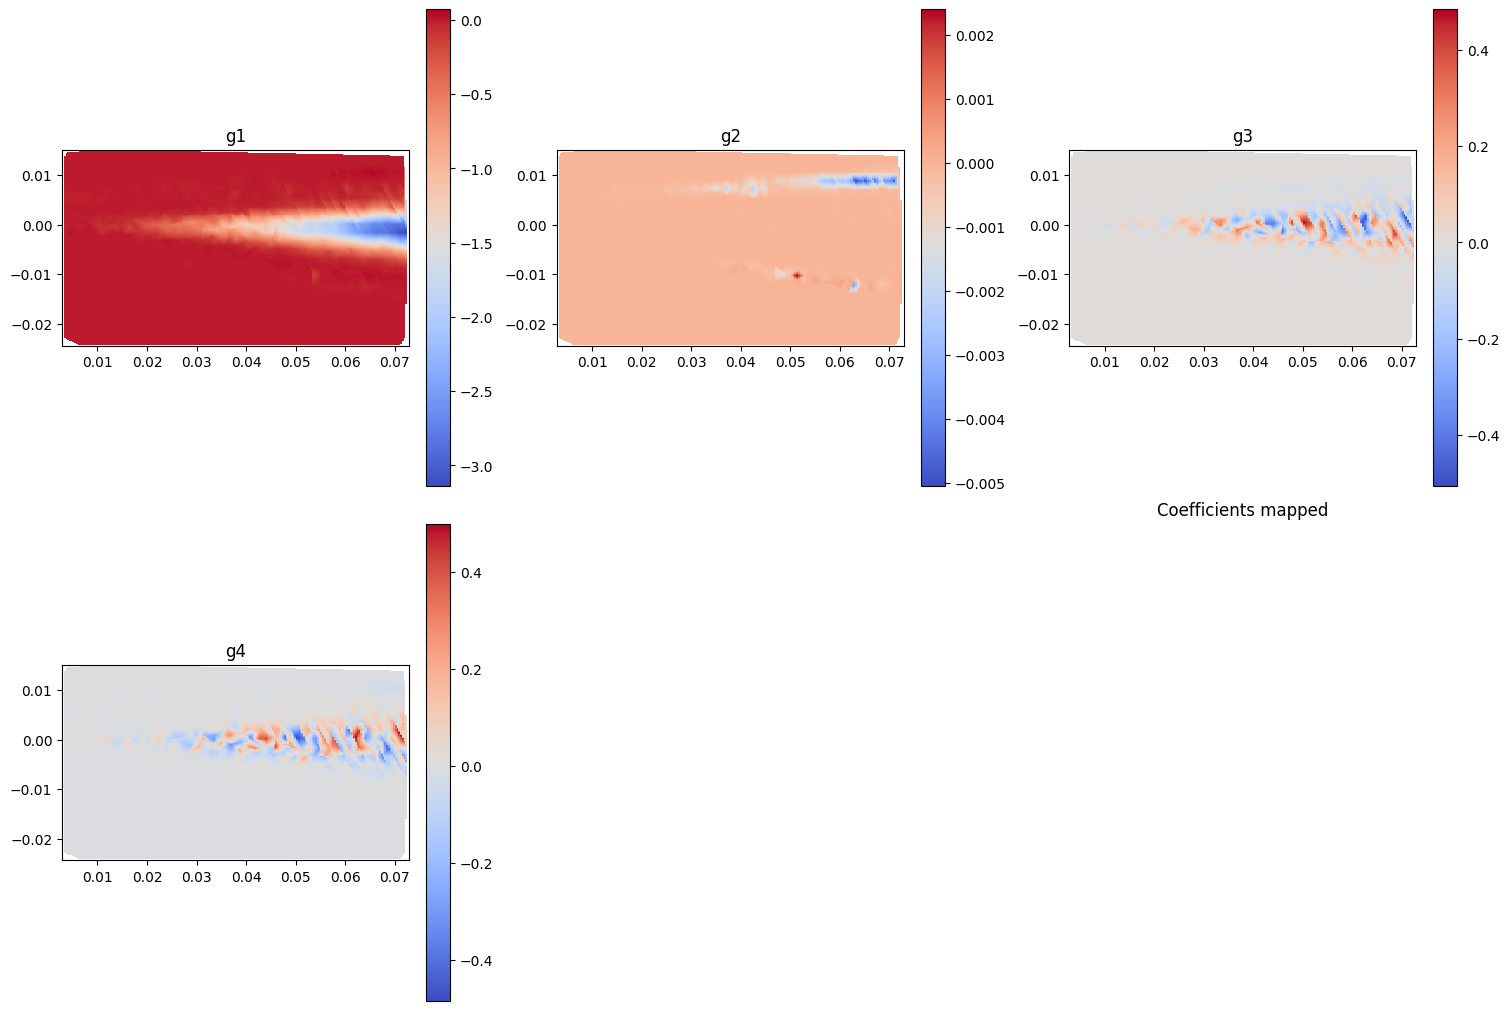

In [381]:
## config
cfg_key = 'reduced'
cfg = configs[cfg_key]
cfg['tensors'] = ["S", "S2_dev", "S_dev2", 'R2']
cfg['invariants'] = ["tr_S", "tr_S2"]
g_all, g_k_all, invariants = run_analysis(cfg)


plot_g_coeffs(g_all, k_norm=False)
if not cfg['norm']['enabled']:
    plot_g_coeffs(g_k_all, k_norm=True)


title = f'{dnd}'
plot_all_g(Cx, Cy, g_all, knorm=False)
if not cfg['norm']['enabled']:
    plot_all_g(Cx, Cy, g_k_all, knorm=True)

#### Plot histograms of tensor basis coefficients

In [12]:
def plot_g_histograms(g_all, title_suffix=""):
    Ng = g_all.shape[1]
    fig, axs = plt.subplots(1, Ng, figsize=(5*Ng, 4))

    for i in range(Ng):
        axs[i].hist(g_all[:, i], bins=80, color='steelblue')
        axs[i].set_title(f"g{i+1} {title_suffix}")

    plt.tight_layout()
    plt.show()

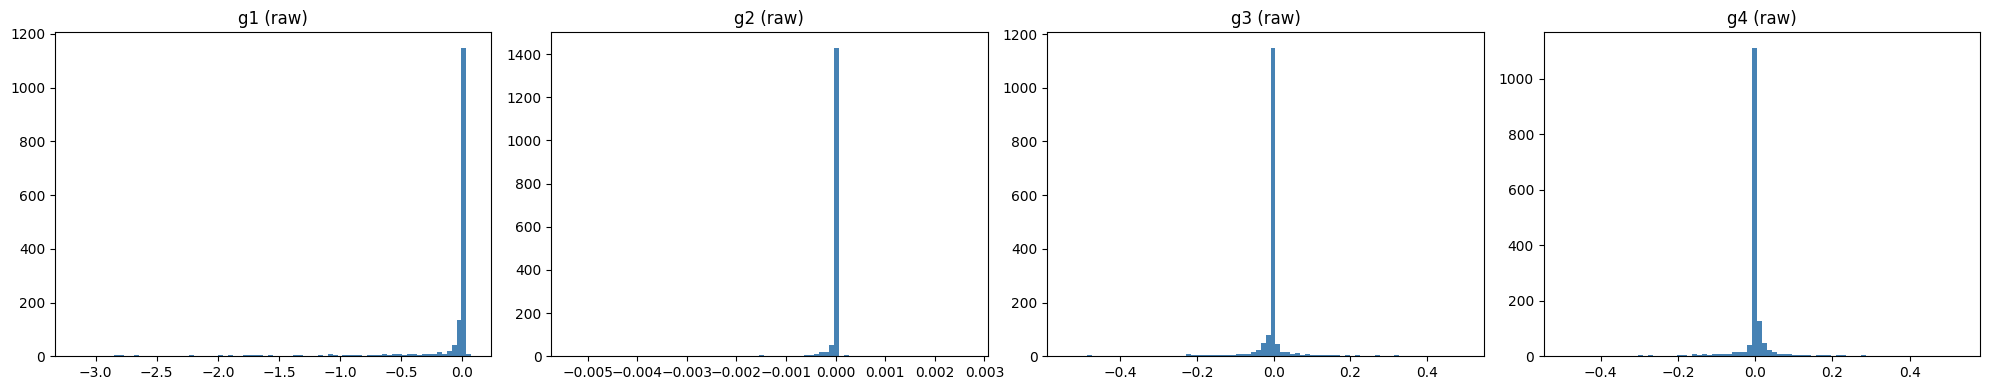

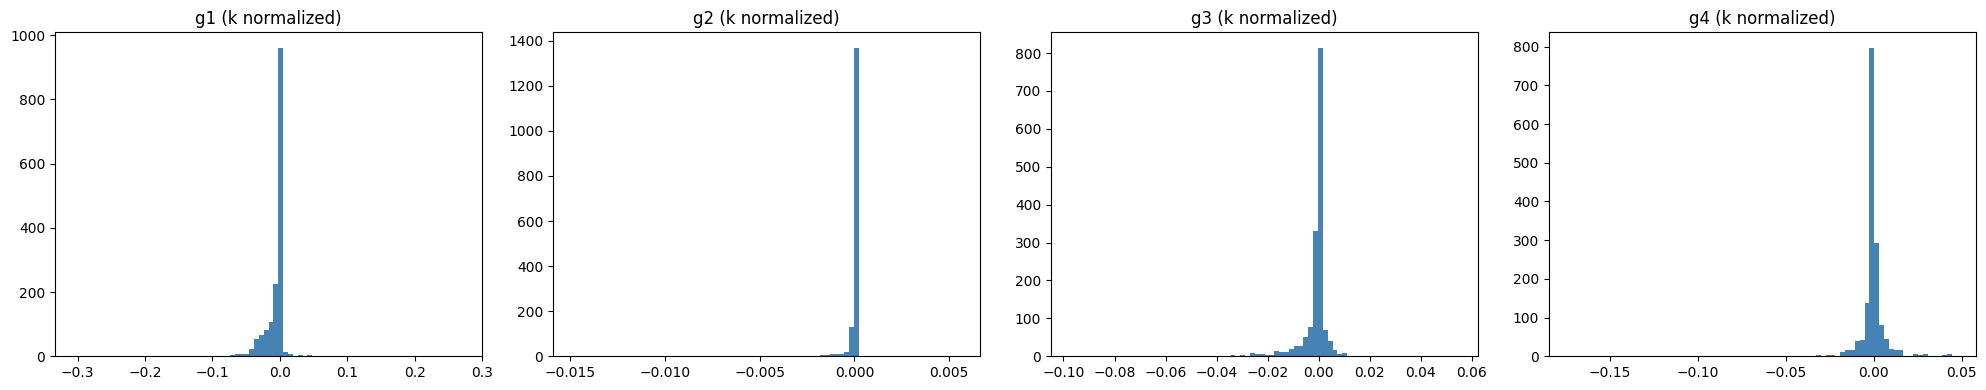

In [382]:
plot_g_histograms(g_all, title_suffix="(raw)")
plot_g_histograms(g_k_all, title_suffix="(k normalized)")

#### Plot scatter of invariants vs coefficients

In [15]:
def plot_invariants_vs_coeffs(invariants, g_all, max_points=None, knorm=False):

    inv_names = list(invariants.keys())
    Ng = g_all.shape[1]
    Ni = len(inv_names)

    # optional downsampling
    if max_points is not None:
        idx = np.linspace(0, len(g_all)-1, max_points).astype(int)
        g_plot = g_all[idx]
        inv_plot = {k: np.array(v)[idx] for k,v in invariants.items()}
    else:
        g_plot = g_all
        inv_plot = invariants

    fig, axes = plt.subplots(
        Ni, Ng,
        figsize=(4*Ng, 3*Ni),
        squeeze=False
    )

    for i, inv_name in enumerate(inv_names):
        x = inv_plot[inv_name]

        for j in range(Ng):
            ax = axes[i][j]
            ax.scatter(x, g_plot[:, j], s=5, alpha=0.5)

            if i == 0:
                ax.set_title(f"g{j+1}")

            if j == 0:
                ax.set_ylabel(inv_name)
    if knorm:
        plt.title("K Normed coefficients vs invariants")
    else:
        plt.title("Coefficients vs invariants")
    plt.tight_layout()
    plt.show()


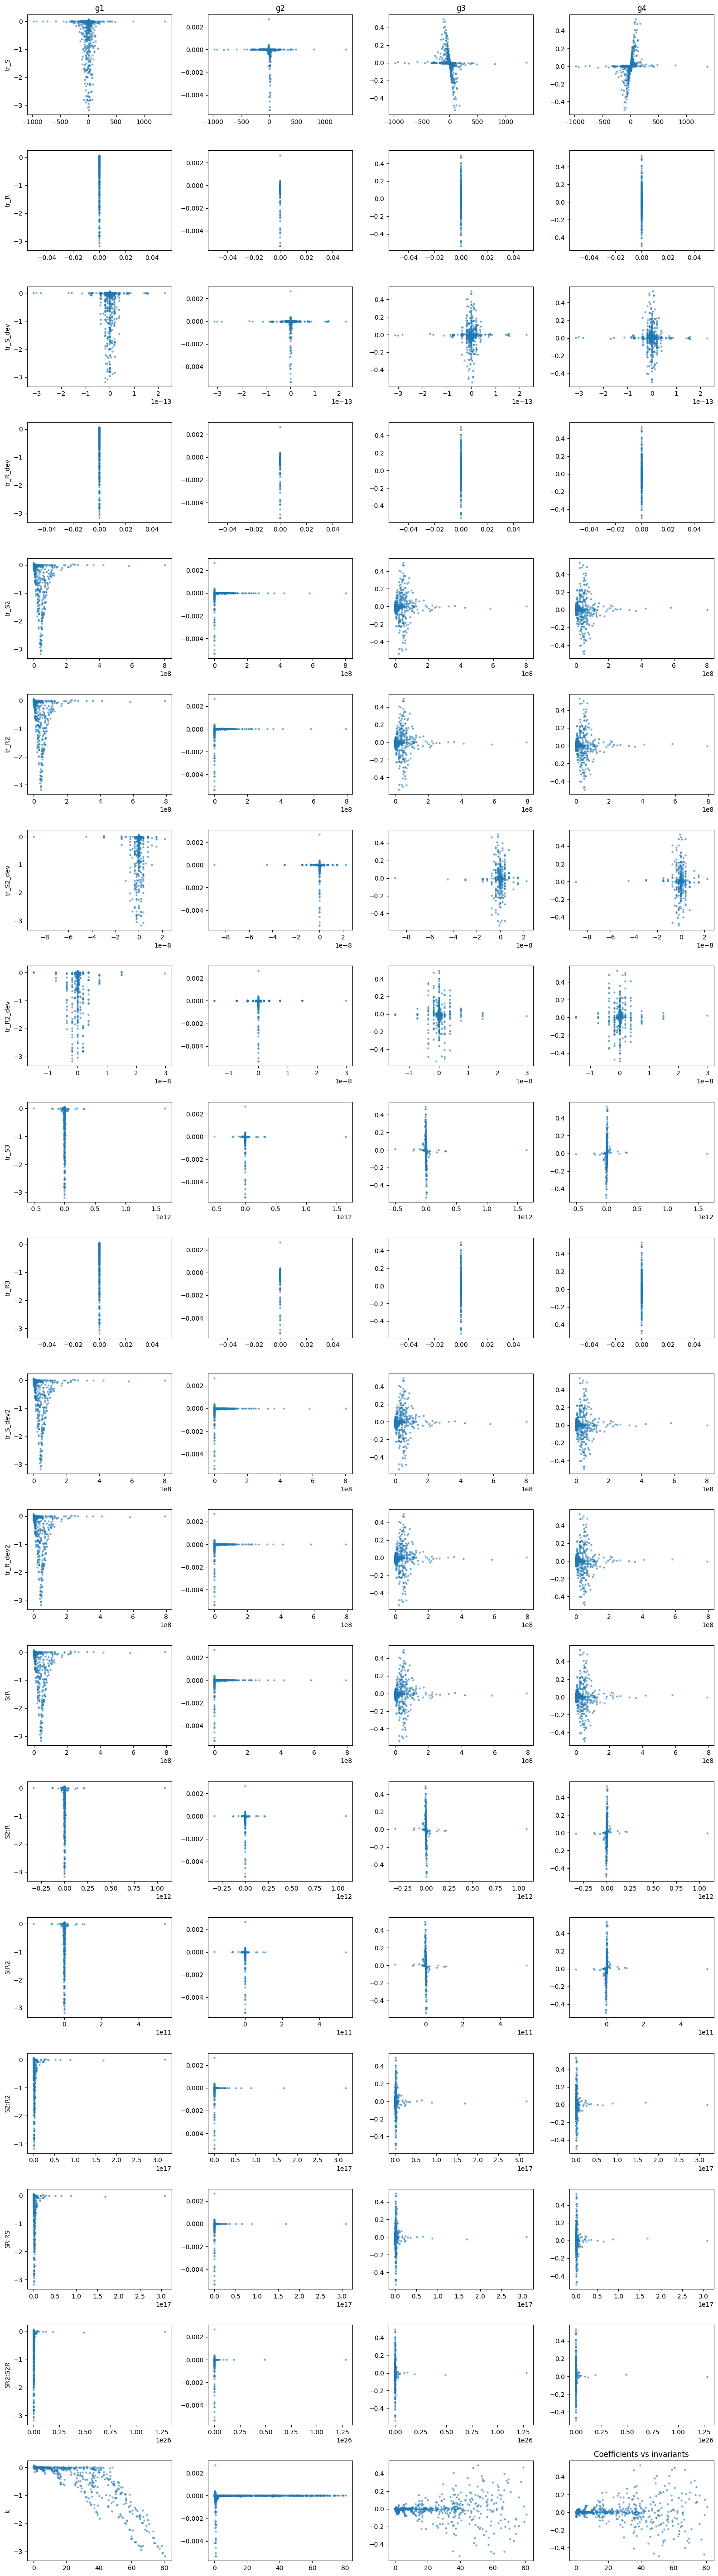

In [384]:
# ---- Invariant relationship grid ----
plot_invariants_vs_coeffs(invariants, g_all, knorm=False)
if not cfg['norm']['enabled']:
    plot_invariants_vs_coeffs(invariants, g_k_all, knorm=True)


#### Plot heatmap of coefficient correlation

In [18]:
def plot_g_correlation(g_all, cmap='coolwarm', knorm=False):
    """
    Plot correlation matrix between TBNN coefficients g_i.
    """
    Ng = g_all.shape[1]
    labels = [f"g{i+1}" for i in range(Ng)]

    corr = np.corrcoef(g_all.T)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)

    # colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Correlation", fontsize=12)

    # ticks
    ax.set_xticks(range(Ng))
    ax.set_yticks(range(Ng))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    
    # rotate tick labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # grid overlay
    ax.set_xticks(np.arange(-.5, Ng, 1), minor=True)
    ax.set_yticks(np.arange(-.5, Ng, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # annotate cell values
    for i in range(Ng):
        for j in range(Ng):
            ax.text(j, i, f"{corr[i,j]:.2f}",
                    ha='center', va='center',
                    color='black', fontsize=10)
    if knorm:
        ax.set_title("K normed coefficients correlation", fontsize=11)
    else:
        ax.set_title("Coefficient Correlation Matrix", fontsize=11)

    plt.tight_layout()
    plt.show()

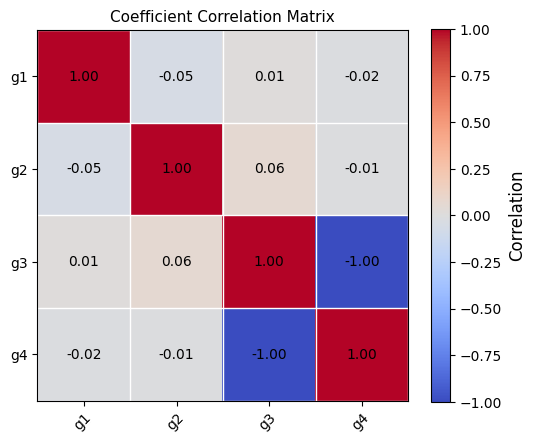

In [383]:
plot_g_correlation(g_all, knorm=False)
if not cfg['norm']['enabled']:
    plot_g_correlation(g_k_all, knorm=True)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_tensor_basis_fields(Cx, Cy,tensor_basis,
                             tensor_name,
                             smooth=True,
                             grid=200,
                             cmap='jet',
                             shading='auto'):
    """
    Plot all 9 components of a 3×3 tensor field on the Cx–Cy grid.

    tensor_basis : dict containing keys:
        - 'Cx', 'Cy' : coordinate fields (1D or N×1)
        - tensor_name : a key whose value is an array [..., 3, 3]
    tensor_name : str
        Name of the tensor to plot (e.g., 'S', 'S_dev', 'R2_dev')
    smooth : bool
        If True, interpolate onto a regular grid.
    """

    assert 'Cx' in tensor_basis and 'Cy' in tensor_basis, "tensor_basis must contain 'Cx' and 'Cy'"
    assert tensor_name in tensor_basis, f"{tensor_name} not found in tensor_basis"

    
    T = np.asarray(tensor_basis[tensor_name])   # shape [N, 3, 3]

    N = T.shape[0]
    assert T.shape == (N, 3, 3), f"{tensor_name} must be [N,3,3] but got {T.shape}"

    # Prepare grid for interpolation
    if smooth:
        X = np.linspace(Cx.min(), Cx.max(), grid)
        Y = np.linspace(Cy.min(), Cy.max(), grid)
        xx, yy = np.meshgrid(X, Y)

    # --- Create figure ---
    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    fig.suptitle(f"{tensor_name} Tensor Components", fontsize=18)

    # 3×3 components
    for i in range(3):
        for j in range(3):
            ax = axes[i, j]

            comp = T[:, i, j]

            if smooth:
                zz = griddata((Cx, Cy), comp, (xx, yy), method='linear')

                pcm = ax.pcolormesh(xx, yy, zz,
                                    shading=shading,
                                    cmap=cmap,
                                    vmin=np.nanmin(zz),
                                    vmax=np.nanmax(zz))
            else:
                pcm = ax.scatter(Cx, Cy, c=comp, s=2, cmap=cmap)

            ax.set_title(f"{tensor_name}[{i},{j}]")
            ax.set_xlabel("Cx")
            ax.set_ylabel("Cy")

            # shared limits
            ax.set_xlim(Cx.min(), Cx.max())
            ax.set_ylim(Cy.min(), Cy.max())

            fig.colorbar(pcm, ax=ax)

    plt.tight_layout()
    plt.show()
